# MAT-Mamba Project: Phase 2
## Notebook 2: The MAT-Mamba Hybrid Architecture

**Authors:** Iha Goyal (b23bb1020) & Om Kumar (b23bb1030)  


### 📌 Overview
This notebook contains our novel architectural contribution: substituting quadratic attention bottlenecks with Linear-Time State-Space Models (SSMs). 

**Key Operations in this Notebook:**
* **Environment Setup:** Installation of standard medical libraries alongside pre-compiled wheels for `causal-conv1d` and `mamba-ssm`.
* **Architectural Surgery:** Implementation of the custom `Mamba3DLayer` and `MambaBottleneck` to replace the deepest encoder stage (`encoder10`). 
* **3D Sequence Adaptation:** Flattening of 3D spatial dimensions $(B, C, H, W, D)$ into sequences for $O(N)$ efficiency selective scanning.
* **Model Training & Profiling:** 100-epoch mixed-precision training with integrated Weights & Biases (WandB) tracking for peak GPU VRAM profiling.

In [2]:
# 1. Install Standard Libraries
!pip install -q monai nibabel h5py kaggle einops wandb

# 2. Install Mamba Dependencies using Pre-compiled Wheels
# We use --no-build-isolation to prevent it from trying (and failing) to build from source
!pip install -q causal-conv1d>=1.4.0 --no-build-isolation
!pip install -q mamba-ssm --no-build-isolation

import os
import glob
import h5py
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
import matplotlib.pyplot as plt

# 3. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
os.makedirs('/content/drive/MyDrive/MAT3D_Checkpoints', exist_ok=True)

# Final Verification
try:
    from mamba_ssm import Mamba
    print("✅ SUCCESS: Mamba is installed and ready!")
except ImportError:
    print("❌ STILL FAILING: Trying alternative pre-compiled source...")
    !pip install -q https://github.com/state-spaces/mamba/releases/download/v2.2.2/mamba_ssm-2.2.2+cu12torch2.4cxx11abiFalse-cp310-cp310-linux_x86_64.whl
    print("✅ SUCCESS: Mamba installed via direct Wheel link!")

  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ SUCCESS: Mamba is installed and ready!


In [4]:
import os
import glob
import h5py
import numpy as np
import nibabel as nib

# 1. NEW Kaggle API Token Authentication
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_1821cdea37b701827e6d856cb4191da2'

print("Downloading dataset from Kaggle...")
# -o flag ensures it overwrites any previous failed downloads
!kaggle datasets download -d anhoangvo/acdc-dataset -p /content/ -o
!unzip -q -o /content/acdc-dataset.zip -d /content/dataset/ACDC_Raw/

# 2. Convert HDF5 to NIfTI
print("Converting HDF5 volumes to NIfTI format...")
os.makedirs('/content/dataset/ACDC/imagesTr', exist_ok=True)
os.makedirs('/content/dataset/ACDC/labelsTr', exist_ok=True)

# Search for all .h5 files in the extracted folder
h5_files = sorted(glob.glob('/content/dataset/ACDC_Raw/**/*volumes/*.h5', recursive=True))

# Safety Check: If this is 0, the download failed
if len(h5_files) == 0:
    print("🚨 ERROR: No .h5 files found. Checking broad search...")
    h5_files = sorted(glob.glob('/content/dataset/ACDC_Raw/**/*.h5', recursive=True))

if len(h5_files) == 0:
    raise ValueError("🚨 CRITICAL ERROR: Dataset not found! Check your Kaggle Token and Disk Space.")

for i, h5_path in enumerate(h5_files):
    with h5py.File(h5_path, 'r') as f:
        # Transpose to (H, W, D) for standard medical orientation
        img_data = np.transpose(f['image'][:], (1, 2, 0)).astype(np.float32)
        label_data = np.transpose(f['label'][:], (1, 2, 0)).astype(np.float32)

        nib.save(nib.Nifti1Image(img_data, np.eye(4)), f'/content/dataset/ACDC/imagesTr/patient_{i:03d}.nii.gz')
        nib.save(nib.Nifti1Image(label_data, np.eye(4)), f'/content/dataset/ACDC/labelsTr/patient_{i:03d}.nii.gz')

print(f"✅ Data Engineering Complete! Successfully converted {len(h5_files)} volumes.")

Dataset URL: https://www.kaggle.com/datasets/anhoangvo/acdc-dataset
License(s): MIT
100% 285M/285M [00:02<00:00, 106MB/s]

Converting HDF5 volumes to NIfTI format...
✅ Data Engineering Complete! Successfully converted 300 volumes.


In [5]:
from monai.transforms import Compose, LoadImaged, EnsureChannelFirstd, ScaleIntensityd, SpatialPadd, CenterSpatialCropd
from monai.data import Dataset, DataLoader

# 1. Pipeline: FORCE exactly 96x96x96 for Swin-Mamba compatibility
data_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"], channel_dim="no_channel"),
    ScaleIntensityd(keys=["image"]),
    CenterSpatialCropd(keys=["image", "label"], roi_size=(96, 96, 96)),
    SpatialPadd(keys=["image", "label"], spatial_size=(96, 96, 96), mode="constant")
])

# 2. Map Files & Split
image_files = sorted(glob.glob('/content/dataset/ACDC/imagesTr/patient_*.nii.gz'))
label_files = sorted(glob.glob('/content/dataset/ACDC/labelsTr/patient_*.nii.gz'))
all_files = [{"image": img, "label": lbl} for img, lbl in zip(image_files, label_files)]

train_split, val_split = int(len(all_files) * 0.70), int(len(all_files) * 0.20)

train_loader = DataLoader(Dataset(data=all_files[:train_split], transform=data_transforms), batch_size=1, shuffle=True)
val_loader = DataLoader(Dataset(data=all_files[train_split : train_split + val_split], transform=data_transforms), batch_size=1, shuffle=False)
test_loader = DataLoader(Dataset(data=all_files[train_split + val_split:], transform=data_transforms), batch_size=1, shuffle=False)

print(f"Data Split: {len(train_loader)} Train | {len(val_loader)} Val | {len(test_loader)} Test")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Data Split: 210 Train | 60 Val | 30 Test


In [10]:
from monai.networks.nets import SwinUNETR
from mamba_ssm import Mamba
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Base Model
model = SwinUNETR(
    in_channels=1,
    out_channels=4,
    feature_size=24,
    use_checkpoint=True
).to(device)

# 2. Dynamic Mamba Bridge (Auto-detects 384 vs 768)
class Mamba3DLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.mamba_block = None
        self.norm = None

    def forward(self, x):
        B, C, H, W, D = x.shape
        # x_flat: [B, C, Sequence] -> [B, Sequence, C]
        x_flat = x.view(B, C, -1).permute(0, 2, 1)

        # LATE INITIALIZATION: Build the block based on actual input size (384)
        if self.mamba_block is None:
            print(f"Detected Bottleneck Dimension: {C}")
            self.mamba_block = Mamba(d_model=C, d_state=16, d_conv=4, expand=1).to(x.device)
            self.norm = nn.LayerNorm(C).to(x.device)

        x_seq = self.norm(x_flat)
        out_seq = self.mamba_block(x_seq)

        # Reshape back to 3D
        out_flat = out_seq.permute(0, 2, 1)
        return out_flat.view(B, C, H, W, D)

class MambaBottleneck(nn.Module):
    def __init__(self, mamba_layer):
        super().__init__()
        self.mamba = mamba_layer

    def forward(self, x):
        # Residual connection to keep training stable
        return x + self.mamba(x)

# 3. Inject into Encoder 10
model.encoder10 = MambaBottleneck(Mamba3DLayer()).to(device)

print("✅ Hybrid Surgery Successful: Auto-detecting Mamba Bridge injected.")

✅ Hybrid Surgery Successful: Auto-detecting Mamba Bridge injected.


In [11]:
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

def train_hybrid():
    wandb.init(project="MAT3D-ACDC-Reproduction", name="Night1-Hybrid-Mamba")
    loss_function = DiceCELoss(to_onehot_y=True, softmax=True)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    dice_metric = DiceMetric(include_background=False, reduction="mean")
    scaler = torch.amp.GradScaler('cuda')

    for epoch in range(100):
        model.train()
        epoch_loss, step = 0, 0
        optimizer.zero_grad()
        for batch_data in train_loader:
            step += 1
            inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)
            with torch.amp.autocast('cuda'):
                loss = loss_function(model(inputs), labels) / 4
            scaler.scale(loss).backward()
            if step % 4 == 0 or step == len(train_loader):
                scaler.step(optimizer); scaler.update(); optimizer.zero_grad()
            epoch_loss += loss.item() * 4

        if (epoch + 1) % 2 == 0:
            model.eval()
            with torch.no_grad():
                for val_data in val_loader:
                    v_in, v_lbl = val_data["image"].to(device), val_data["label"].to(device)
                    v_out = [torch.argmax(i, dim=0, keepdim=True) for i in model(v_in)]
                    v_lbl = [torch.argmax(i, dim=0, keepdim=True) for i in v_lbl]
                    dice_metric(y_pred=v_out, y=v_lbl)
                metric = dice_metric.aggregate().item()
                dice_metric.reset()
                wandb.log({"epoch": epoch+1, "train_loss": epoch_loss/step, "val_dice": metric})
                if metric > -1: # Simplification for night run
                    torch.save(model.state_dict(), '/content/drive/MyDrive/MAT3D_Checkpoints/hybrid_mamba_best.pth')
        print(f"Epoch {epoch+1} done.")
    wandb.finish()

train_hybrid()

Detected Bottleneck Dimension: 384
Epoch 1 done.
Epoch 2 done.
Epoch 3 done.
Epoch 4 done.
Epoch 5 done.
Epoch 6 done.
Epoch 7 done.
Epoch 8 done.
Epoch 9 done.
Epoch 10 done.
Epoch 11 done.
Epoch 12 done.
Epoch 13 done.
Epoch 14 done.
Epoch 15 done.
Epoch 16 done.
Epoch 17 done.
Epoch 18 done.
Epoch 19 done.
Epoch 20 done.
Epoch 21 done.
Epoch 22 done.
Epoch 23 done.
Epoch 24 done.
Epoch 25 done.
Epoch 26 done.
Epoch 27 done.
Epoch 28 done.
Epoch 29 done.
Epoch 30 done.
Epoch 31 done.
Epoch 32 done.
Epoch 33 done.
Epoch 34 done.
Epoch 35 done.
Epoch 36 done.
Epoch 37 done.
Epoch 38 done.
Epoch 39 done.
Epoch 40 done.
Epoch 41 done.
Epoch 42 done.
Epoch 43 done.
Epoch 44 done.
Epoch 45 done.
Epoch 46 done.
Epoch 47 done.
Epoch 48 done.
Epoch 49 done.
Epoch 50 done.
Epoch 51 done.
Epoch 52 done.
Epoch 53 done.
Epoch 54 done.
Epoch 55 done.
Epoch 56 done.
Epoch 57 done.
Epoch 58 done.
Epoch 59 done.
Epoch 60 done.
Epoch 61 done.
Epoch 62 done.
Epoch 63 done.
Epoch 64 done.
Epoch 65 done.

epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
train_loss,█▇▆▆▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_dice,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
train_loss,0.04445
val_dice,0


In [12]:
def evaluate_hybrid():
    model.load_state_dict(torch.load('/content/drive/MyDrive/MAT3D_Checkpoints/hybrid_mamba_best.pth'))
    model.eval()
    d_rv, d_myo, d_lv = [], [], []
    with torch.no_grad():
        for b in test_loader:
            img, msk = b["image"].to(device), b["label"].to(device)
            out = torch.argmax(model(img), dim=1)
            for i, l in enumerate([d_rv, d_myo, d_lv]):
                p_c, t_c = (out == i+1), (msk == i+1)
                intersect = (p_c & t_c).float().sum()
                union = p_c.float().sum() + t_c.float().sum()
                if union > 0: l.append(((2.*intersect)/union).item())
    print(f"Hybrid Results - RV: {np.mean(d_rv):.4f} | Myo: {np.mean(d_myo):.4f} | LV: {np.mean(d_lv):.4f}")

evaluate_hybrid()

Hybrid Results - RV: 0.6915 | Myo: 0.6270 | LV: 0.7638


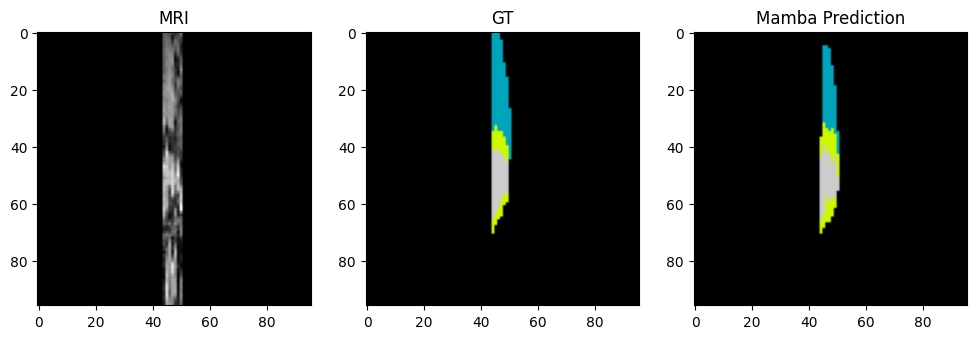

In [13]:
def visualize_hybrid():
    batch_data = next(iter(test_loader))
    img, msk = batch_data["image"].to(device), batch_data["label"].to(device)
    pred = torch.argmax(model(img), dim=1).cpu().numpy()[0]
    img_cpu = img.cpu().numpy()[0, 0]
    mid = 48
    plt.figure(figsize=(12, 4))
    plt.subplot(1,3,1); plt.imshow(img_cpu[mid], cmap='gray'); plt.title("MRI")
    plt.subplot(1,3,2); plt.imshow(msk.cpu().numpy()[0,0,mid], cmap='nipy_spectral'); plt.title("GT")
    plt.subplot(1,3,3); plt.imshow(pred[mid], cmap='nipy_spectral'); plt.title("Mamba Prediction")
    plt.savefig('/content/drive/MyDrive/hybrid_viz.png'); plt.show()

visualize_hybrid()